<a href="https://colab.research.google.com/github/devgmotta/Detec-o_de_Fraude/blob/main/Detec%C3%A7%C3%A3o_de_Fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando Bibliotecas necessárias

In [2]:
# Importações essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para lidar com o desbalanceamento
from imblearn.over_sampling import SMOTE

# Ignorar avisos
import warnings
warnings.filterwarnings('ignore')

# Carrgando e visualizando os dados do DataSet

In [3]:
# Carregar os dados
url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
df = pd.read_csv(url)

# Visualizar as primeiras linhas
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# EDA

Class
0    284315
1       492
Name: count, dtype: int64

Porcentagem de Fraudes: 0.173%


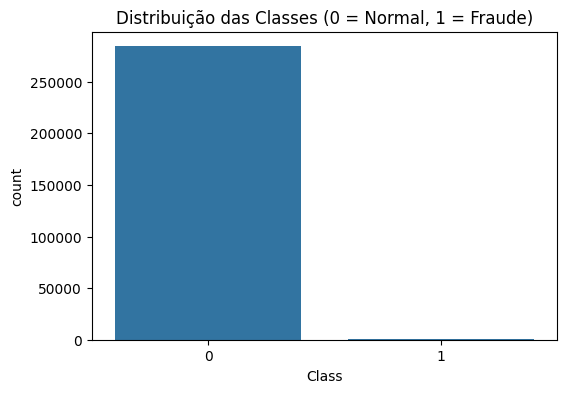

In [4]:
# Verificando o desbalanceamento
print(df['Class'].value_counts())
print("\nPorcentagem de Fraudes: {:.3f}%".format((df[df['Class'] == 1].shape[0] / df.shape[0]) * 100))

# Plotando o desbalanceamento
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribuição das Classes (0 = Normal, 1 = Fraude)')
plt.show()

In [6]:
# Como o dataset está muito desbalanceado, a acurácia não será confiável.
# A alternativa é fazer um oversampling pra não perder dados e evitar ruídos no modelo

# Pré-processamento dos Dados

In [7]:
# Instanciando o scaler
rob_scaler = RobustScaler()

# Criando novas colunas escalonadas
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Removendo as colunas originais e reorganizando
df.drop(['Time','Amount'], axis=1, inplace=True)

# Separando variáveis independentes (X) e alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Separando em Treino e Teste (usando stratify para manter a mesma proporção de fraudes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicando estratégia do oversampling - SMOTE

In [8]:
# Aplicando SMOTE apenas no conjunto de treino!
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribuição antes do SMOTE: {np.bincount(y_train)}")
print(f"Distribuição DEPOIS do SMOTE: {np.bincount(y_train_smote)}")

Distribuição antes do SMOTE: [227451    394]
Distribuição DEPOIS do SMOTE: [227451 227451]


# Treinando e Avaliando os Modelos

### O Dilema do Negócio: Recall vs. Experiência do Cliente

Ao analisar os resultados iniciais, nos deparamos com um trade-off clássico na detecção de fraudes.
A **Regressão Logística** obteve um *Recall* excelente (0.92), capturando quase todas as fraudes. No entanto, sua *Precision* foi de apenas 0.06. Em termos de negócios, isso significa que para cada fraude evitada, o modelo bloquearia o cartão de dezenas de clientes honestos (Falsos Positivos), gerando insatisfação, sobrecarga no call center e possível perda de clientes (Churn).

Por outro lado, o **Random Forest** apresentou um *Recall* um pouco menor (0.82), mas com uma *Precision* de 0.88. Ele deixou passar algumas fraudes a mais, mas incomodou um número ínfimo de clientes legítimos. Para a maioria das instituições financeiras, o custo operacional de milhares de cartões bloqueados injustamente supera o prejuízo de algumas fraudes pontuais. Portanto, o **Random Forest é o modelo escolhido** para seguirmos com o ajuste fino.

--- Avaliação do Modelo: Regressão Logística ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



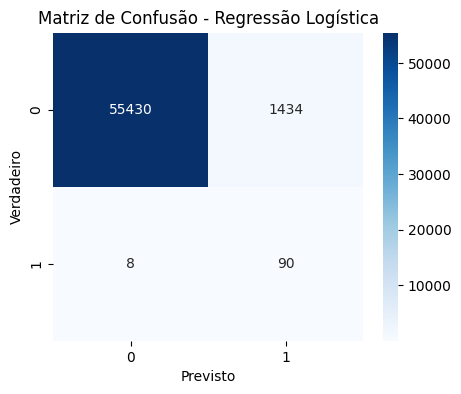

--- Avaliação do Modelo: Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



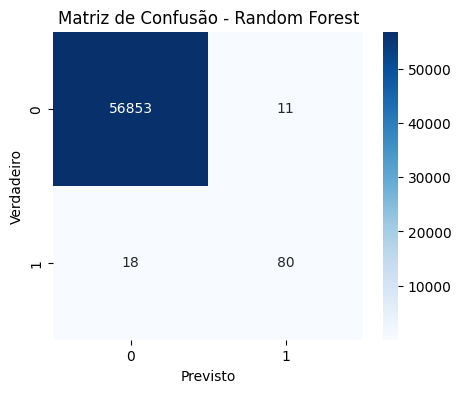

In [9]:
def avaliar_modelo(modelo, X_test, y_test, nome_modelo):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    print(f"--- Avaliação do Modelo: {nome_modelo} ---")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusão
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

# 1. Regressão Logística
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train_smote, y_train_smote)
avaliar_modelo(modelo_lr, X_test, y_test, "Regressão Logística")

# 2. Random Forest (Aviso: pode demorar alguns minutos para treinar)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_smote, y_train_smote)
avaliar_modelo(modelo_rf, X_test, y_test, "Random Forest")

# Feature Importance

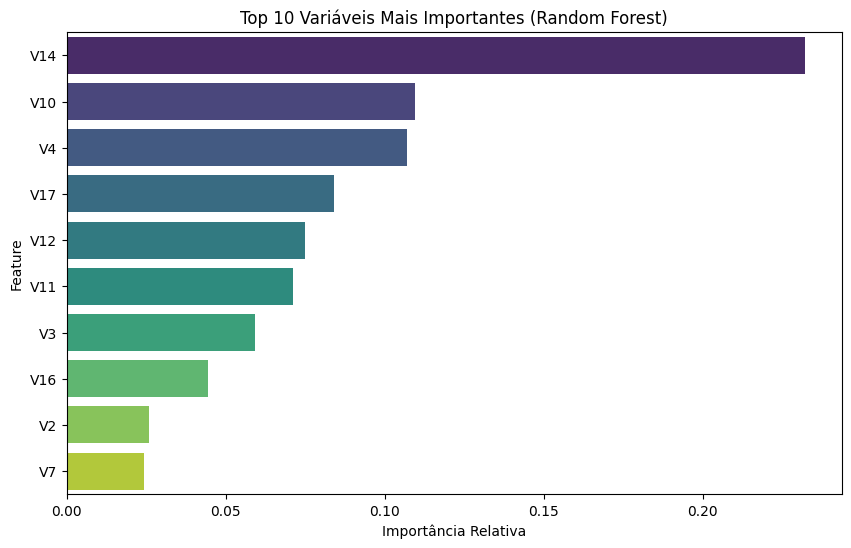

In [10]:
# Verificando qual feature tem mais impacto no modelo
importances = modelo_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=features[indices][:10], palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Feature')
plt.show()

# Curva Precision-Recall (PR AUC)

### Avaliação Definitiva: Curva Precision-Recall

Em datasets altamente desbalanceados (onde as fraudes são menos de 0.2% dos dados), métricas como Acurácia e a tradicional curva ROC AUC podem ser enganosas, pois o modelo acerta muito simplesmente prevendo a classe majoritária.

A métrica técnica definitiva neste cenário é a **Curva Precision-Recall (PR AUC)**. Quanto mais próxima a linha estiver do canto superior direito, melhor o modelo consegue manter a precisão alta enquanto aumenta o recall. Como podemos ver no gráfico a seguir, o Random Forest demonstra uma excelente performance com uma Average Precision (AP) de 0.87.

<Figure size 800x600 with 0 Axes>

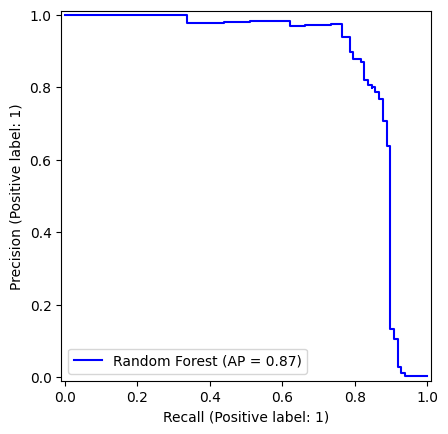

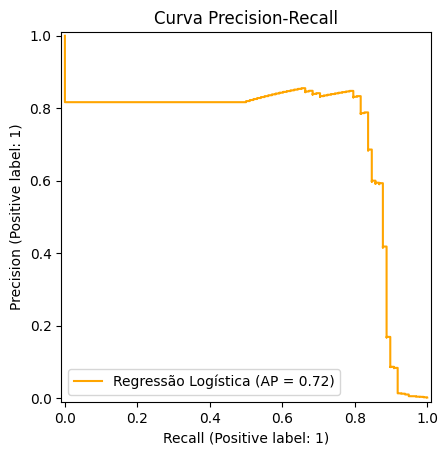

In [11]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(modelo_rf, X_test, y_test, name='Random Forest', color='blue')
PrecisionRecallDisplay.from_estimator(modelo_lr, X_test, y_test, name='Regressão Logística', color='orange')
plt.title('Curva Precision-Recall')
plt.show()

- A curva que estiver mais próxima do canto superior direito é a melhor.

# Ajuste do Ponto de Corte (Threshold)

### Ajuste Fino para Negócios: Otimizando o Threshold (Ponto de Corte)

Por padrão, os algoritmos de Machine Learning classificam uma transação como fraude se a probabilidade calculada for maior que 50% (0.50). Porém, em problemas de fraude, podemos ser um pouco mais conservadores.

Se reduzirmos esse limite (Threshold) para **30% (0.30)**, estamos dizendo ao modelo: *"Se você tiver 30% de certeza de que é uma fraude, já considere como suspeito"*.

Abaixo, testamos esse novo ponto de corte. O resultado foi o "ponto de equilíbrio" ideal: conseguimos subir o *Recall* para **0.88** (capturando mais fraudes do que o padrão do Random Forest), mantendo uma *Precision* muito saudável de **0.72** (muito superior aos 0.06 da Regressão Logística).

In [12]:
# Analisando as probabilidades do Random Forest
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Criando um novo threshold (ex: se tiver 30% de chance, já bloqueia)
novo_threshold = 0.30
y_pred_customizado = (y_prob_rf >= novo_threshold).astype(int)

print(f"--- Avaliação com Threshold de {novo_threshold} ---")
print(classification_report(y_test, y_pred_customizado))

--- Avaliação com Threshold de 0.3 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962

